# Data Exploration & Feature Engineering

This notebook covers the cleaning and exploration of the SDSS galaxy dataset. We aim to see how galaxies are distributed across color indices and spot difficult color-color regions where redshift estimation becomes challenging. By understanding the dataset early on, we can make better decisions during the feature engineering and modeling phases.

In [1]:
import numpy as np
import pandas as pd
import pickle
import plotly.express as px

from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from astroML.datasets import fetch_sdss_specgals
from astroML.utils.decorators import pickle_results
from sklearn.model_selection import train_test_split
from scipy.ndimage import uniform_filter

## 1. Data Fetching and Feature Engineering

First, we load the dataset and create our main features. We use the `modelMag` columns to calculate four primary color indices: $u-g$, $g-r$, $r-i$, and $i-z$. These adjacent color differences are important because they help track large spectral features, like the 4000 Å break, as a galaxy's redshift changes.

In [2]:
# Get the data
data = fetch_sdss_specgals()
df = pd.DataFrame(data)
print("Raw data shape:", data.shape)

# Calculate the Color Indices
df['u-g'] = df['modelMag_u'] - df['modelMag_g']
df['g-r'] = df['modelMag_g'] - df['modelMag_r']
df['r-i'] = df['modelMag_r'] - df['modelMag_i']
df['i-z'] = df['modelMag_i'] - df['modelMag_z']

Raw data shape: (661598,)


## 2. Data Cleaning & Train/Test Splitting

Machine learning pipelines for redshift are very sensitive to bad measurements, so we filter out noisy observations. We also exclude galaxies with $z < 0.02$. Testing showed that placing a hard boundary here or higher causes a regression-to-the-mean edge effect, pulling nearby predictions up. Using $z > 0.02$ keeps most of the data while pushing this artifact to the very edge of the local universe. The cleaned dataset is then split into training, validation, and testing sets.

In [3]:
# Filtering Parameters
mag_err = 1
z_min = 0.02

# Filter the dataset
df_clean = df[
    (df['modelMagErr_u'] < mag_err) &
    (df['modelMagErr_g'] < mag_err) &
    (df['modelMagErr_r'] < mag_err) &
    (df['modelMagErr_i'] < mag_err) &
    (df['modelMagErr_z'] < mag_err) &
    (df['z'] > z_min)
]

# Creating the feature and target datasets
X = df_clean[['u-g', 'g-r', 'r-i', 'i-z']]
y = df_clean['z']

@pickle_results('data/dataset_clean.pkl')
def split_data(X_data, y_data):
    X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

# Doing a 70/15/15 split of dataset
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

# Locally saving the full dataset without splits
with open('data/full_dataset_clean.pkl', 'wb') as file:
    pickle.dump(df_clean, file)

@pickle_results: using precomputed results from 'data/dataset_clean.pkl'


## 3. Redshift Distribution

Looking at the distribution of spectroscopic redshift ($z$) gives us a quick sense of our sample. Since spectroscopic redshift is our highly accurate "ground truth," this histogram shows where our training data is thickest and where our models will likely perform best.

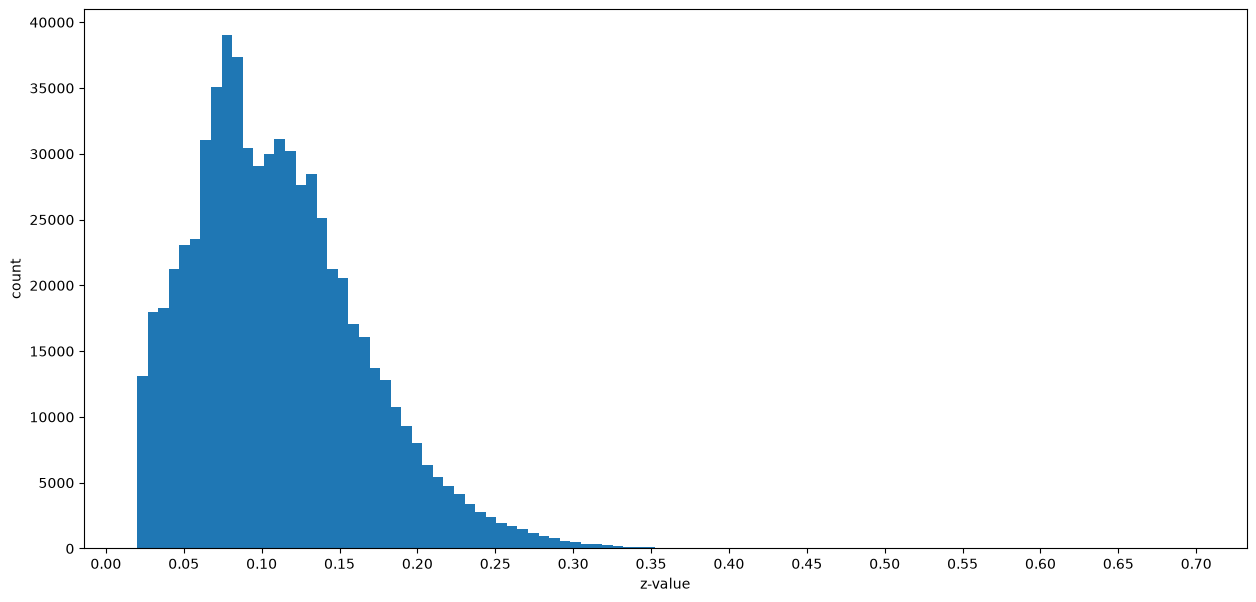

In [4]:
# Creating the z-value distribution using a histogram
fig, ax = plt.subplots(figsize=(15,7))
ax.hist(df['z'], bins=100)
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.set_xlabel("z-value")
ax.set_ylabel("count")
plt.show()

## 4. Degenerate Regions in Color-Color Space

Some areas in color-color space are "degenerate," meaning galaxies with similar colors can have very different actual redshifts. These regions represent a hard limit on accuracy. By calculating the standard deviation of redshift within 2D color bins, we can map out these problem areas. High standard deviations within a tight color boundary strongly signal a degenerate region.

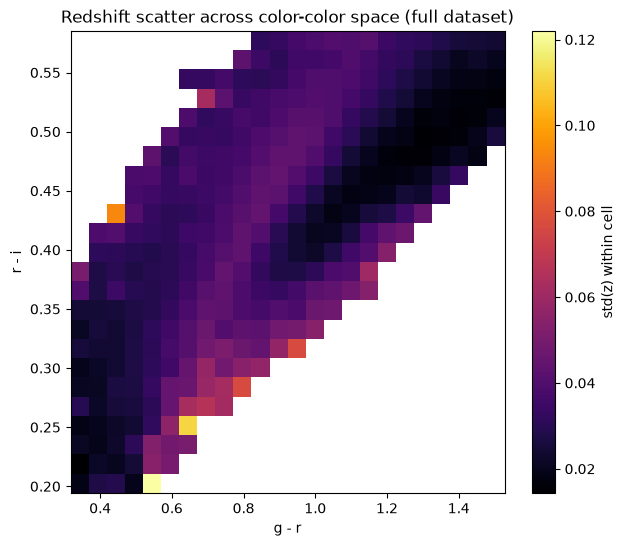

In [5]:
# Load the full dataset
with open('data/full_dataset_clean.pkl', 'rb') as file:
    full_df = pickle.load(file)

# Get the colors
g_r = full_df['g-r'].values
r_i = full_df['r-i'].values
z = full_df['z'].values

# Exclude outliers from data
g_r_low, g_r_high = np.percentile(g_r, [1, 99])
r_i_low, r_i_high = np.percentile(r_i, [1, 99])

# Create bins
g_r_bins = np.linspace(g_r_low, g_r_high, 25)
r_i_bins = np.linspace(r_i_low, r_i_high, 25)

# Create the grid
z_std_cell = np.full((len(g_r_bins)-1, len(r_i_bins)-1), np.nan)
count_cell = np.zeros_like(z_std_cell)

# Building a 2D histogram and compute std(z) for each cell in grid
for i in range(len(g_r_bins) - 1):
    for j in range(len(r_i_bins) - 1):
        mask = (
            (g_r >= g_r_bins[i]) & (g_r < g_r_bins[i+1]) &
            (r_i >= r_i_bins[j]) & (r_i < r_i_bins[j+1])
        )
        n = mask.sum()
        count_cell[i,j] = n
        if(n >= 20):
            z_std_cell[i,j] = z[mask].std()

# Plot the 2D color-color space
plt.figure(figsize=(7, 6))
plt.imshow(z_std_cell.T, origin='lower', aspect='auto', cmap='inferno',
           extent=[g_r_bins[0], g_r_bins[-1], r_i_bins[0], r_i_bins[-1]])
plt.colorbar(label='std(z) within cell')
plt.xlabel('g - r')
plt.ylabel('r - i')
plt.title('Redshift scatter across color-color space (full dataset)')
plt.show()

### 4.1 Locating the Top Degenerate Boundaries

To find the most difficult regions, we apply a 2D smoothing filter to our standard deviation grid. This reduces noise from cells with very few galaxies. By sorting the smoothed results, we can pinpoint the exact color boundaries where predictions will naturally struggle. Identifying these intervals allows us to test our models' uncertainty later on.

In [6]:
# Search for a degenerate region
z_std_masked = np.where(count_cell >= 20, z_std_cell, np.nan)
z_std_smooth = uniform_filter(np.nan_to_num(z_std_masked), size=3)
valid_smooth = uniform_filter((count_cell >= 20).astype(float), size=3)
z_std_smooth = np.divide(z_std_smooth, valid_smooth, out=np.full_like(z_std_smooth, np.nan), where=valid_smooth > 0.5)

# Print the top 5 regions
flat_sorted = np.argsort(np.nan_to_num(z_std_smooth, nan=-1).ravel())[::-1][:5]
table_data = []
for rank, idx in enumerate(flat_sorted, start=1):
    i, j = np.unravel_index(idx, z_std_smooth.shape)
    
    table_data.append({
        "Rank": rank,
        "g-r Range": f"[{g_r_bins[i]:.3f}, {g_r_bins[i+1]:.3f}]",
        "r-i Range": f"[{r_i_bins[j]:.3f}, {r_i_bins[j+1]:.3f}]",
        "Std Dev (Smoothed)": round(z_std_smooth[i, j], 6),
        "Count (N)": int(count_cell[i, j])
    })

# Convert to a DataFrame and display it
results_df = pd.DataFrame(table_data)
display(results_df.style.hide(axis='index'))

Rank,g-r Range,r-i Range,Std Dev (Smoothed),Count (N)
1,"[0.671, 0.721]","[0.243, 0.260]",0.070474,19
2,"[0.671, 0.721]","[0.260, 0.276]",0.067012,43
3,"[0.721, 0.772]","[0.260, 0.276]",0.065139,25
4,"[0.620, 0.671]","[0.227, 0.243]",0.063178,27
5,"[0.570, 0.620]","[0.211, 0.227]",0.063081,23


## 5. Visualizing the Redshift Track

By looking only at the highest-quality observations, we can clearly see how galaxy colors shift with redshift. The data forms a twisting, overlapping track in 3D space rather than a simple straight line. This complex shape explains why basic linear models struggle and why we need non-linear machine learning.

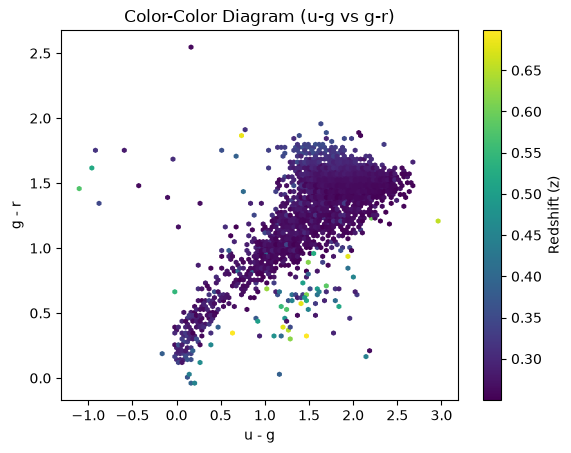

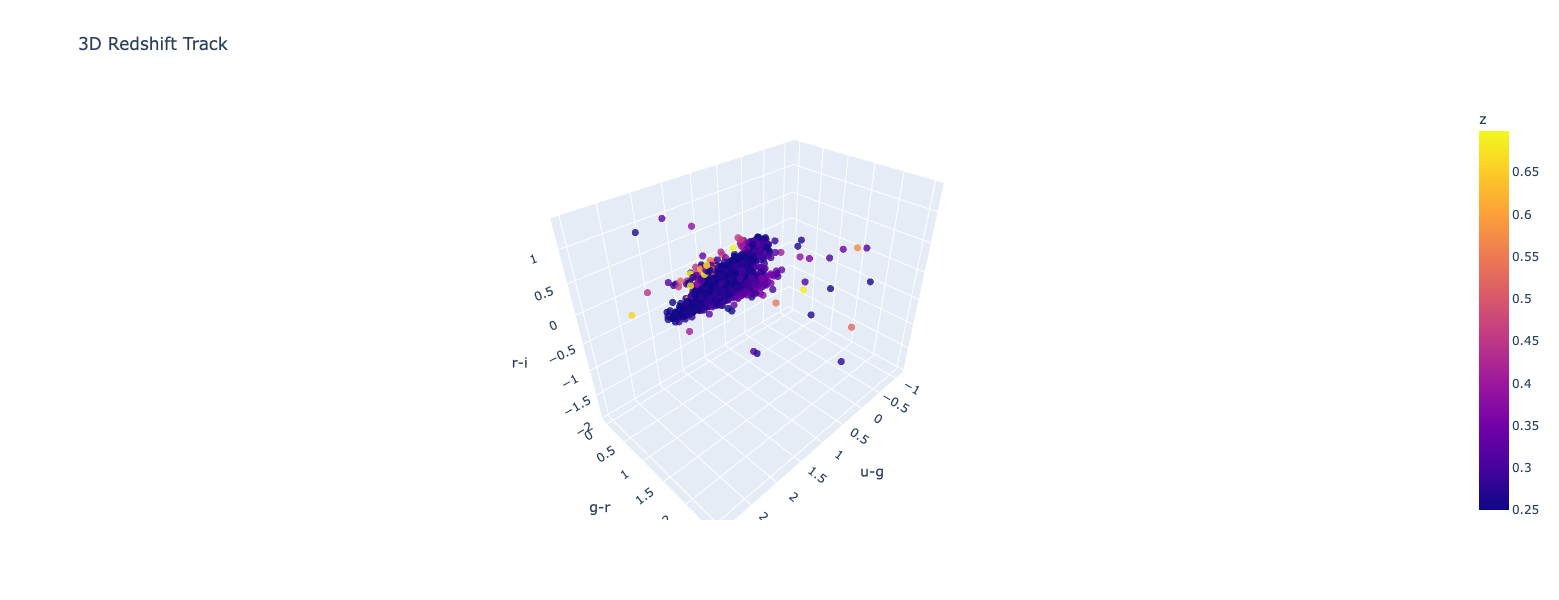

In [7]:
model_mag_error = 0.25

# We use stricter error bounds to isolate the redshift track structure
df_plot = df[
    (df['modelMagErr_u'] < model_mag_error) &
    (df['modelMagErr_g'] < model_mag_error) &
    (df['modelMagErr_r'] < model_mag_error) &
    (df['modelMagErr_i'] < model_mag_error) &
    (df['modelMagErr_z'] < model_mag_error) &
    (df['z'] > 0.25) # Filter the low-z blob for clarity
]

# 2D Hexbin
hb = plt.hexbin(df_plot['u-g'], df_plot['g-r'], C=df_plot['z'], cmap='viridis')
plt.xlabel('u - g')
plt.ylabel('g - r')
plt.title('Color-Color Diagram (u-g vs g-r)')
cb = plt.colorbar(hb)
cb.set_label('Redshift (z)')
plt.show()

# 3D Interactive Plot
fig = px.scatter_3d(
    df_plot, 
    x='u-g', 
    y='g-r', 
    z='r-i',
    color='z',
    color_continuous_scale='Plasma',
    title='3D Redshift Track'
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.update_layout(width=800, height=600)
fig.show()